# Кредитный скоринг (EDA)

Изучение данных и связи признаков с выходом в дефолт.

## Подготовка окружения

Подключение библиотек и настройка вычислений на видеокарте.

In [1]:
import os
import gc
import glob
import json
import time
import warnings

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as pads
import torch
import torch.nn as nn
from abc import ABC, abstractmethod
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

DEVICE = 'cuda'
AMP_DTYPE = torch.bfloat16
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

print('torch', torch.__version__, '|', torch.cuda.get_device_name(0))

torch 2.0.1+cu118 | Tesla T4


## Параметры

Основные настройки обучения и ансамбля.

In [2]:
SEED = 42
BATCH = 8192
np.random.seed(SEED)
torch.manual_seed(SEED)

NN_FOLDS = 5
GBDT_FOLDS = 5
N_SEEDS = 1

PATIENCE = 5
MODEL_EPOCHS = {
    'gru': 10,
    'transformer': 15,
    'cnn': 18,
    'transformer_hier': 15,
}

EMA_DECAY = 0.999
EMA_EVERY = 4
VAL_SUBSAMPLE = 100_000

MAX_LEN = 50
D_MODEL = 256
GRU_LAYERS = 2
TF_LAYERS = 3
TF_FF = 1024
MAX_LR = 2e-3

USE_CACHE = True
CACHE_VERSION = 'v2'
SAVE_MODELS = True
RESUME = True
FINETUNE = True

PL_EPOCHS = 5
PL_POS_Q = 0.8
PL_NEG_Q = 0.99
PL_MAX_NEG_MULT = 10

MODEL_PARAMS = {
    'xgboost': dict(learning_rate=0.02, max_depth=7, min_child_weight=5,
                    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, gamma=0.0),
    'gru': dict(d_model=256, gru_layers=2, dropout=0.2, max_lr=2e-3, weight_decay=1e-5),
    'transformer': dict(d_model=256, tf_layers=3, tf_ff=1024, dropout=0.1,
                        max_lr=2e-3, weight_decay=1e-5),
    'cnn': dict(d_model=256, tcn_levels=4, dropout=0.1, max_lr=2e-3, weight_decay=1e-5),
    'transformer_hier': dict(d_model=256, hier_layers=4, hier_hidden_mult=2, dropout=0.1,
                             max_lr=1.2e-3, weight_decay=0.02, grad_clip=1.0, label_smooth=0.02),
}

print('BATCH', BATCH, '| фолды', NN_FOLDS, '| сиды', N_SEEDS, '| resume', RESUME)
print('finetune', FINETUNE, '| эпохи по моделям:', MODEL_EPOCHS)

BATCH 8192 | фолды 5 | сиды 1 | resume True
finetune True | эпохи по моделям: {'gru': 10, 'transformer': 15, 'cnn': 18, 'transformer_hier': 15}


## Расположение файлов

Исходные данные находятся рядом с ноутбуком. Здесь же задаются папки для сохранения моделей и промежуточных результатов; если предобработка уже сохранена, повторная подготовка не требуется.

In [3]:
OUT = os.getcwd()
SAVE_DIR = os.path.join(OUT, 'models')
CACHE_DIR = os.path.join(OUT, 'cache')
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

CACHE_KEYS = [
    'X_agg', 'X_test', 'y', 'ids_tr', 'ids_te',
    'tr_first', 'tr_cnt', 'tr_feats', 'tr_rn',
    'te_first', 'te_cnt', 'te_feats', 'te_rn',
]

def cache_path(name):
    return os.path.join(CACHE_DIR, f'{CACHE_VERSION}_{name}')

cache_ready = (
    USE_CACHE
    and os.path.exists(cache_path('meta.json'))
    and all(os.path.exists(cache_path(key + '.npy')) for key in CACHE_KEYS)
)

TRAIN = os.path.join(OUT, 'train_data.parquet')
TEST = os.path.join(OUT, 'test_data.parquet')
TGT = os.path.join(OUT, 'train_target.csv')
SUB = os.path.join(OUT, 'sample_submission.csv')

print('кэш:', 'есть' if cache_ready else 'нет', '| рабочая папка:', OUT)

кэш: есть | рабочая папка: /home/jupyter/alpha


## Предобработка данных

Функции для загрузки данных, построения агрегированных признаков по истории клиента и формирования последовательностей продуктов фиксированной длины.

In [4]:
def load_parquet(path):
    dataset = pads.dataset(path, format='parquet')
    columns = {}
    for name in dataset.schema.names:
        array = dataset.to_table(columns=[name]).column(0).combine_chunks()
        dtype = pa.int32() if name == 'id' else pa.int8()
        columns[name] = array.cast(dtype).to_numpy(zero_copy_only=False)
        del array
        gc.collect()
    frame = pd.DataFrame(columns)
    del columns
    gc.collect()
    return frame

In [5]:
def aggregate(df):
    df = df.copy()

    paym_cols = [c for c in df.columns if c.startswith('enc_paym_')]
    if paym_cols:
        df['n_bad_paym'] = (df[paym_cols].values >= 3).sum(1).astype(np.int16)

    overdue_cols = [c for c in ['pre_loans5', 'pre_loans530', 'pre_loans3060',
                                'pre_loans6090', 'pre_loans90'] if c in df.columns]
    if overdue_cols:
        df['tot_overdue'] = df[overdue_cols].sum(1).astype(np.int16)

    if 'pre_loans_outstanding' in df and 'pre_loans_credit_limit' in df:
        limit = df['pre_loans_credit_limit'].astype(np.float32) + 1
        df['util_ratio'] = (df['pre_loans_outstanding'] / limit).astype(np.float32)
    if 'pre_loans_next_pay_summ' in df and 'pre_loans_credit_limit' in df:
        limit = df['pre_loans_credit_limit'].astype(np.float32) + 1
        df['nextpay_ratio'] = (df['pre_loans_next_pay_summ'] / limit).astype(np.float32)

    flag_cols = [c for c in df.columns if c.startswith('is_zero') or c.endswith('_flag')]
    feat_cols = [c for c in df.columns if c not in ('id', 'rn')]
    numeric_cols = [c for c in feat_cols if c not in flag_cols]

    grouped = df.groupby('id', sort=True)

    stats = grouped[numeric_cols].agg(['min', 'max', 'mean', 'std', 'sum'])
    stats.columns = [f'{col}_{fn}' for col, fn in stats.columns]
    flag_means = grouped[flag_cols].mean().add_suffix('_mean')
    counts = grouped.size().rename('n_records').to_frame()
    last_vals = df.loc[grouped['rn'].idxmax()].set_index('id')[feat_cols].add_suffix('_last')
    first_vals = df.loc[grouped['rn'].idxmin()].set_index('id')[feat_cols].add_suffix('_first')

    nunique_cols = [c for c in ['enc_loans_credit_type', 'enc_loans_credit_status']
                    if c in df.columns]
    parts = [counts, stats, flag_means, last_vals, first_vals]
    if nunique_cols:
        parts.append(grouped[nunique_cols].nunique().add_suffix('_nunique'))

    features = pd.concat(parts, axis=1).astype(np.float32).fillna(0.0)
    for col in numeric_cols:
        if f'{col}_last' in features.columns and f'{col}_first' in features.columns:
            features[f'{col}_delta'] = (
                features[f'{col}_last'].values - features[f'{col}_first'].values)

    del stats, flag_means, counts, last_vals, first_vals, grouped, df
    gc.collect()
    return features

In [6]:
def build_sequences(df, seq_cols):
    df = df.sort_values(['id', 'rn'], kind='stable')
    ids = df['id'].values
    feats = (df[seq_cols].values.astype(np.int16) + 1).astype(np.int8)
    rn = df['rn'].values.astype(np.int8)
    uniq, first_idx, counts = np.unique(ids, return_index=True, return_counts=True)
    return uniq, first_idx.astype(np.int64), counts.astype(np.int32), feats, rn


def build_padded(first, cnt, feats, rn, max_len):
    n_clients = len(first)
    n_rows, n_feat = feats.shape
    row_client = np.repeat(np.arange(n_clients), cnt)

    position = np.arange(n_rows) - first[row_client]
    keep = np.minimum(cnt, max_len)
    shifted = position - (cnt - keep)[row_client]
    visible = shifted >= 0

    padded_feats = np.zeros((n_clients, max_len, n_feat), dtype=np.int8)
    padded_rn = np.zeros((n_clients, max_len), dtype=np.int8)
    padded_feats[row_client[visible], shifted[visible]] = feats[visible]
    padded_rn[row_client[visible], shifted[visible]] = rn[visible]
    return padded_feats, padded_rn, keep.astype(np.int16)

## Подготовка данных

Данные либо загружаются из ранее сохранённого результата, либо собираются заново и сохраняются для следующих запусков. Подготовленные последовательности переносятся на видеокарту.

In [7]:
if cache_ready:
    X_agg_np = np.load(cache_path('X_agg.npy'))
    X_test_agg_np = np.load(cache_path('X_test.npy'))
    y = np.load(cache_path('y.npy'))
    ids_train = np.load(cache_path('ids_tr.npy'))
    ids_test = np.load(cache_path('ids_te.npy'))
    tr_first = np.load(cache_path('tr_first.npy'))
    tr_cnt = np.load(cache_path('tr_cnt.npy'))
    tr_feats = np.load(cache_path('tr_feats.npy'))
    tr_rn = np.load(cache_path('tr_rn.npy'))
    te_first = np.load(cache_path('te_first.npy'))
    te_cnt = np.load(cache_path('te_cnt.npy'))
    te_feats = np.load(cache_path('te_feats.npy'))
    te_rn = np.load(cache_path('te_rn.npy'))
    meta = json.load(open(cache_path('meta.json')))
    SEQ_COLS = meta['SEQ_COLS']
    VOCAB = {k: int(v) for k, v in meta['VOCAB'].items()}
    NF = meta['NF']
    feat_cols_agg = meta['feat']
    print('кэш загружен | X_agg', X_agg_np.shape)
else:
    target = pd.read_csv(TGT)
    train_df = load_parquet(TRAIN)

    SEQ_COLS = [c for c in train_df.columns if c not in ('id', 'rn')]
    VOCAB = {c: int(train_df[c].max()) + 2 for c in SEQ_COLS}
    NF = len(SEQ_COLS)

    train_agg = aggregate(train_df)
    ids_train = train_agg.index.values
    feat_cols_agg = train_agg.columns.tolist()
    X_agg_np = train_agg.values.astype(np.float32)
    del train_agg
    gc.collect()

    y = target.set_index('id').reindex(ids_train)['flag'].values.astype(np.int8)
    _, tr_first, tr_cnt, tr_feats, tr_rn = build_sequences(train_df, SEQ_COLS)
    del train_df
    gc.collect()

    test_df = load_parquet(TEST)
    test_agg = aggregate(test_df).reindex(columns=feat_cols_agg, fill_value=0.0)
    ids_test = test_agg.index.values
    X_test_agg_np = test_agg.values.astype(np.float32)
    del test_agg
    gc.collect()
    _, te_first, te_cnt, te_feats, te_rn = build_sequences(test_df, SEQ_COLS)
    del test_df
    gc.collect()

    saved = {
        'X_agg': X_agg_np, 'X_test': X_test_agg_np, 'y': y,
        'ids_tr': ids_train, 'ids_te': ids_test,
        'tr_first': tr_first, 'tr_cnt': tr_cnt, 'tr_feats': tr_feats, 'tr_rn': tr_rn,
        'te_first': te_first, 'te_cnt': te_cnt, 'te_feats': te_feats, 'te_rn': te_rn,
    }
    for name, value in saved.items():
        np.save(cache_path(name + '.npy'), value)
    json.dump({'SEQ_COLS': SEQ_COLS, 'VOCAB': VOCAB, 'NF': NF, 'feat': feat_cols_agg},
              open(cache_path('meta.json'), 'w'))
    print('данные построены и сохранены в', CACHE_DIR)

n_test = len(te_first)

кэш загружен | X_agg (2100000, 457)


## Разведочный анализ

Краткий обзор выборки и того, как отдельные характеристики клиента связаны с выходом в дефолт.

Доля клиентов в дефолте и изменение частоты дефолта с ростом длины кредитной истории.

клиентов: 2100000
признаков-агрегатов: 457
доля дефолтов: 3.55%
история: медиана 7 продуктов, максимум 55


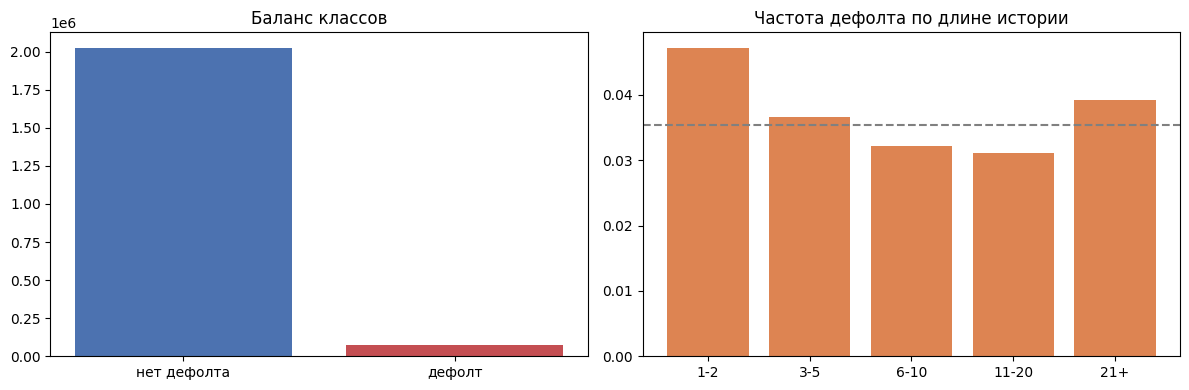

In [8]:
import matplotlib.pyplot as plt

median_len = int(np.median(tr_cnt))
print('клиентов:', len(y))
print('признаков-агрегатов:', X_agg_np.shape[1])
print('доля дефолтов: {:.2%}'.format(float(y.mean())))
print('история: медиана {} продуктов, максимум {}'.format(median_len, int(tr_cnt.max())))

length = np.clip(tr_cnt, 1, MAX_LEN)
bins = [0, 2, 5, 10, 20, MAX_LEN]
labels = ['1-2', '3-5', '6-10', '11-20', '21+']
bucket = pd.cut(length, bins=bins, labels=labels, include_lowest=True)
rate_by_len = pd.DataFrame({'len': bucket, 'y': y}).groupby('len', observed=True)['y'].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
balance = pd.Series(y).value_counts().sort_index()
ax[0].bar(['нет дефолта', 'дефолт'], balance.values, color=['#4c72b0', '#c44e52'])
ax[0].set_title('Баланс классов')
ax[1].bar(rate_by_len.index.astype(str), rate_by_len.values, color='#dd8452')
ax[1].axhline(float(y.mean()), color='gray', linestyle='--')
ax[1].set_title('Частота дефолта по длине истории')
plt.tight_layout()
plt.show()

Насколько каждый признак сам по себе разделяет должников и платящих клиентов. Чем выше значение, тем сильнее связь признака с дефолтом.

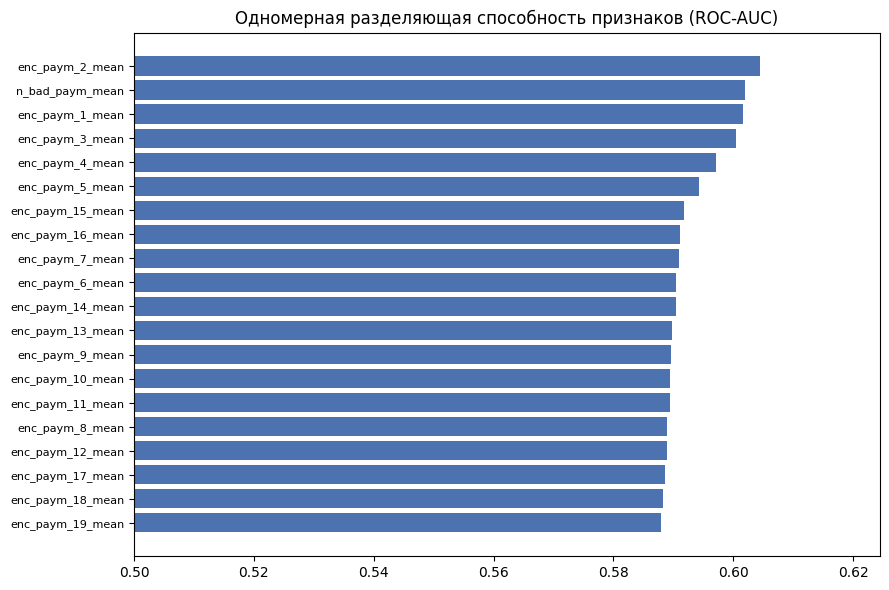

In [9]:
rng = np.random.default_rng(SEED)
sample_size = min(150_000, len(y))
sample_idx = rng.choice(len(y), sample_size, replace=False)
y_sample = y[sample_idx]
X_sample = X_agg_np[sample_idx]

feature_auc = np.full(X_sample.shape[1], 0.5)
for j in range(X_sample.shape[1]):
    column = X_sample[:, j]
    if np.ptp(column) == 0:
        continue
    score = roc_auc_score(y_sample, column)
    feature_auc[j] = max(score, 1 - score)

order = np.argsort(feature_auc)[::-1][:20]
top_names = [feat_cols_agg[j] for j in order]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(order)), feature_auc[order][::-1], color='#4c72b0')
ax.set_yticks(range(len(order)))
ax.set_yticklabels(top_names[::-1], fontsize=8)
ax.set_xlim(0.5, float(feature_auc[order].max()) + 0.02)
ax.set_title('Одномерная разделяющая способность признаков (ROC-AUC)')
plt.tight_layout()
plt.show()

Далее оценим вклад признаков по оценке градиентного бустинга.

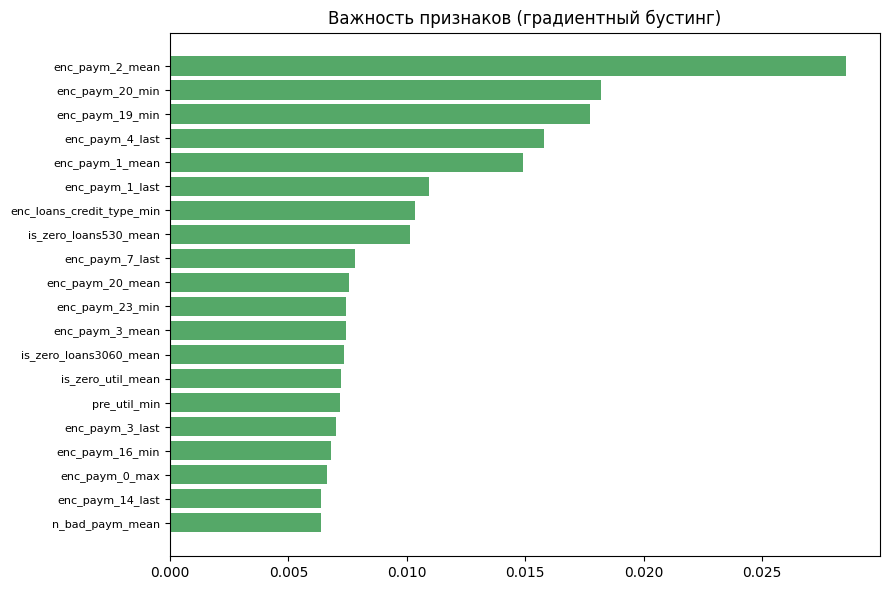

In [10]:
from xgboost import XGBClassifier

eda_gbdt = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='gpu_hist', random_state=SEED, n_jobs=-1,
)
eda_gbdt.fit(X_agg_np, y)
importance = eda_gbdt.feature_importances_

order = np.argsort(importance)[::-1][:20]
top_names = [feat_cols_agg[j] for j in order]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(order)), importance[order][::-1], color='#55a868')
ax.set_yticks(range(len(order)))
ax.set_yticklabels(top_names[::-1], fontsize=8)
ax.set_title('Важность признаков (градиентный бустинг)')
plt.tight_layout()
plt.show()

Связи между наиболее важными признаками.

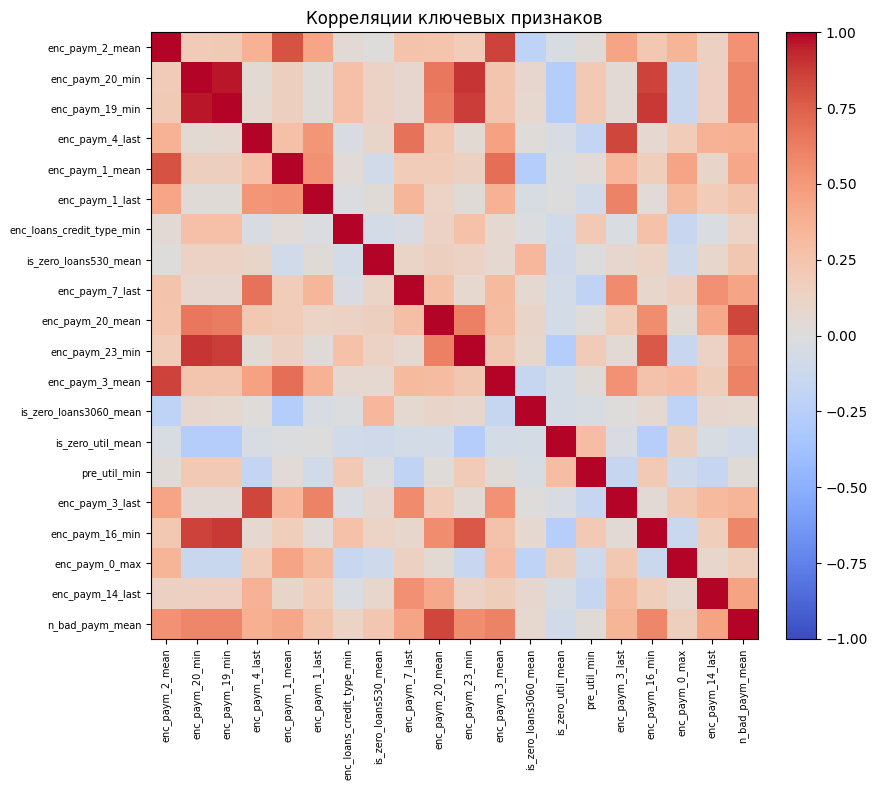

In [11]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(y), min(100_000, len(y)), replace=False)
top_idx = np.argsort(importance)[::-1][:20]
top_names = [feat_cols_agg[j] for j in top_idx]
corr = np.corrcoef(X_agg_np[sample_idx][:, top_idx], rowvar=False)

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(top_idx)))
ax.set_yticks(range(len(top_idx)))
ax.set_xticklabels(top_names, rotation=90, fontsize=7)
ax.set_yticklabels(top_names, fontsize=7)
fig.colorbar(image, fraction=0.046, pad=0.04)
ax.set_title('Корреляции ключевых признаков')
plt.tight_layout()
plt.show()

### Выводы

- Классы сильно несбалансированы, а обучение должно учитыват редкость дефолтов.
- Частота дефолта нелинейно зависит от длины кредитной истории: она выше у клиентов с очень короткой и с очень длинной историей и ниже в середине.
- Ни одна отдельная характеристика не разделяет должников и платящих клиентов уверенно, сигнал слабый и распределён по истории ежемесячных платежей, нужно использовать последовательные модели и может быть оправдано объединение моделей.
- Многие характеристики во многом дублируют друг друга по смыслу, поэтому предпочтительны устойчивые к этому модели.